# **EXOPLANET HABITABILITY CLASSIFICATION PROJECT**

### RIDIMA

This notebook is a ML project, classifying exoplanets on their habitability from various mission data. 

In [284]:
#Import all the essentials libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import dabl as db



from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV,StratifiedKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.utils import resample
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, classification_report, confusion_matrix 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from eli5.sklearn import PermutationImportance




#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier as Ovr
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [218]:
#Open the data
df = pd.read_csv("phl_exoplanet_catalog_2019.csv")
df.head()

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007,2014-05-14,...,0,Hot,0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.86330,1.29
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009,2018-09-06,...,0,Hot,0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.78480,1.53
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008,2014-05-14,...,0,Hot,0,0.081917,Andromeda,And,Andromeda,12.848516,1525.57440,0.83
3,14 Her b,3.0,1481.07850,-47.67420,47.67420,NaN,NaN,NaN,2002,2018-09-06,...,0,Cold,0,0.145241,Hercules,Her,Hercules,12.865261,1481.07850,2.93
4,16 Cyg B b,3.0,565.73385,-25.42624,25.42624,NaN,NaN,NaN,1996,2018-09-06,...,1,Warm,0,0.368627,Cygnus,Cyg,Swan,13.421749,565.73385,1.66


In [219]:
with open("column_names.txt", "w") as f:
    for i, col in enumerate(df.columns, start=1):
        f.write(f"{i}. {col}\n")
df.columns

Index(['P_NAME', 'P_STATUS', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX',
       'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_YEAR',
       'P_UPDATED',
       ...
       'P_HABZONE_CON', 'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI',
       'S_CONSTELLATION', 'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG',
       'P_RADIUS_EST', 'P_MASS_EST', 'P_SEMI_MAJOR_AXIS_EST'],
      dtype='object', length=112)

In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Columns: 112 entries, P_NAME to P_SEMI_MAJOR_AXIS_EST
dtypes: float64(94), int64(4), object(14)
memory usage: 3.5+ MB


In [221]:
shape = df.shape
print(f'Rows: {shape[0]}')
print(f'Columns: {shape[1]}')

Rows: 4048
Columns: 112


Our target column is P_HABITABLE< which is a multiclass column.

Let's visualize the imbalance

# **EDA**

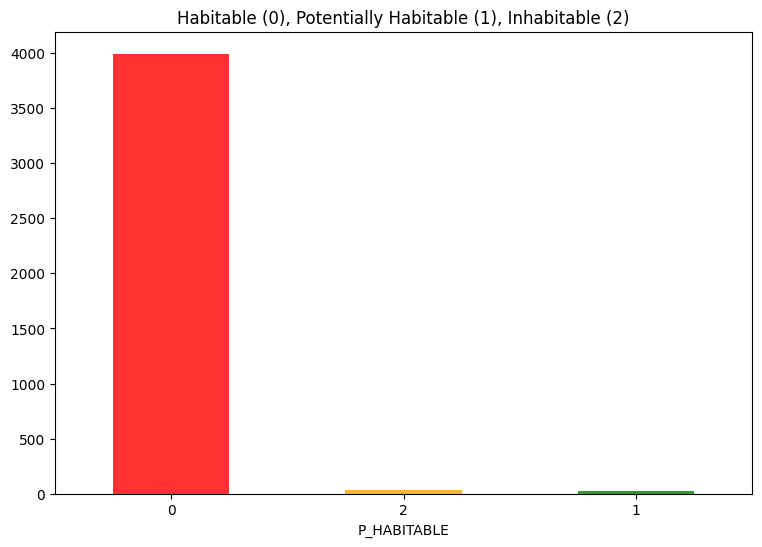

In [222]:
fig = plt.figure(figsize = (9,6))

df.P_HABITABLE.value_counts(ascending=False).plot(kind = 'bar', color= ['red', 'orange', 'green'], alpha = 0.8, rot = 0)

plt.title('Habitable (0), Potentially Habitable (1), Inhabitable (2)')
plt.savefig("Class-Imbalance.png")
plt.show()

Target looks like classification
Showing only top 10 of 84 continuous features
Linear Discriminant Analysis training set score: 0.865


[<Axes: title={'center': 'Target distribution'}, xlabel='count', ylabel='P_HABITABLE'>,
 [<Figure size 2000x600 with 10 Axes>,
  array([[<Axes: title={'center': '0.840'}, xlabel='P_ESI', ylabel='P_TEMP_EQUIL'>,
          <Axes: title={'center': '0.783'}, xlabel='P_ESI', ylabel='P_TEMP_EQUIL_MIN'>,
          <Axes: title={'center': '0.737'}, xlabel='P_ESI', ylabel='P_OMEGA_ERROR_MAX'>,
          <Axes: title={'center': '0.699'}, xlabel='P_ESI', ylabel='S_TIDAL_LOCK'>]],
        dtype=object),
  <Figure size 1600x400 with 4 Axes>,
  <Figure size 400x400 with 1 Axes>],
 array([[<Axes: title={'center': 'P_TYPE_TEMP'}>,
         <Axes: title={'center': 'P_TYPE'}>,
         <Axes: title={'center': 'S_TYPE_TEMP'}>,
         <Axes: title={'center': 'P_DETECTION'}>]], dtype=object)]

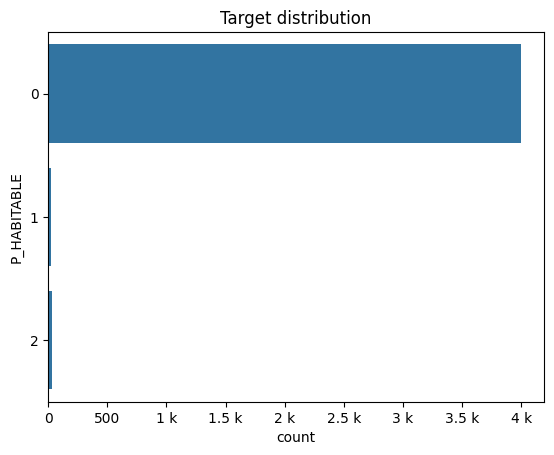

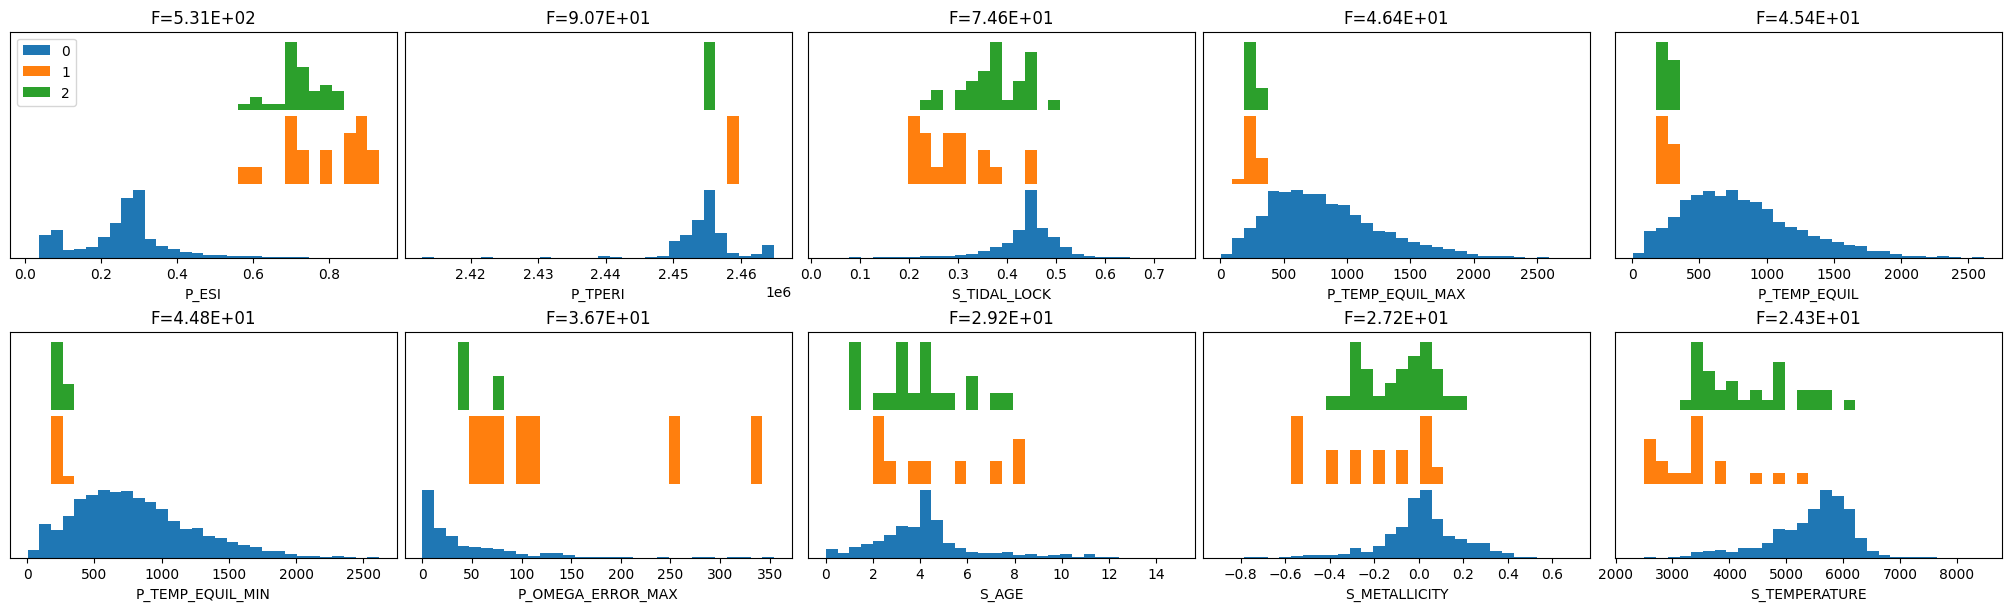

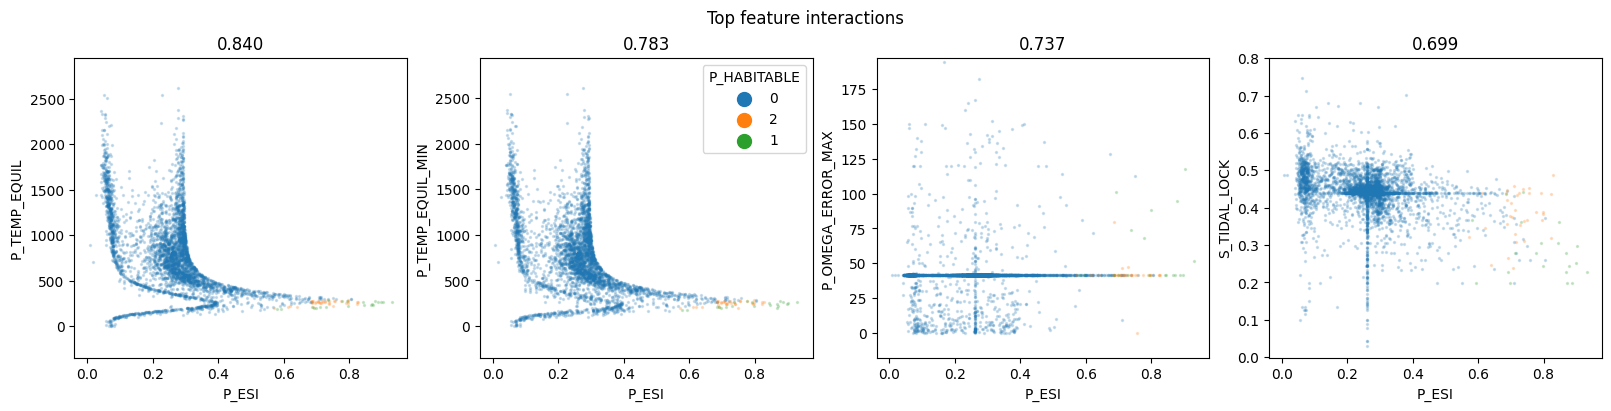

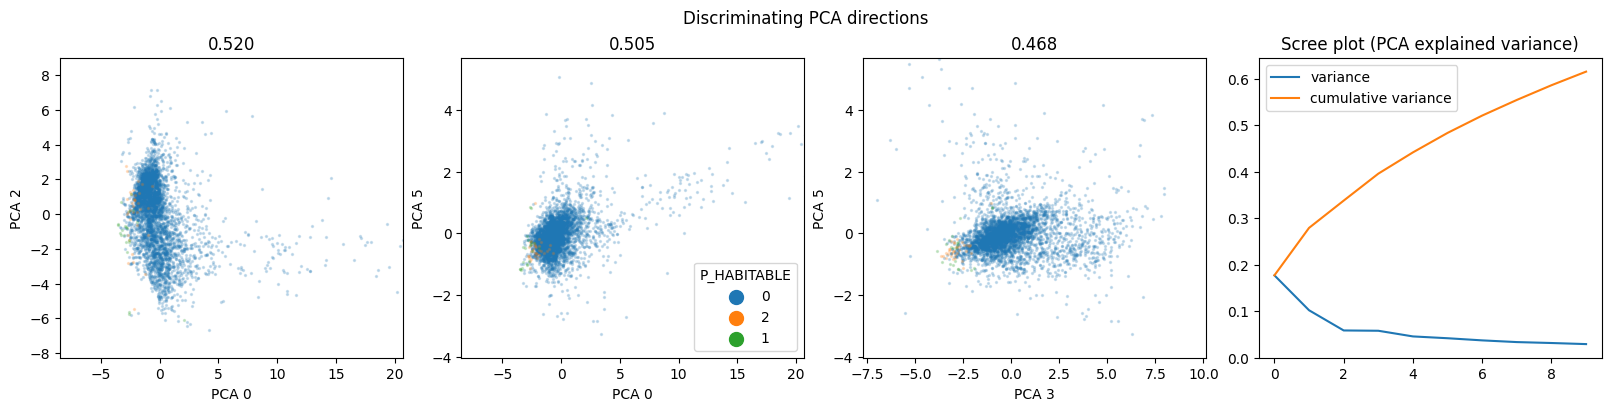

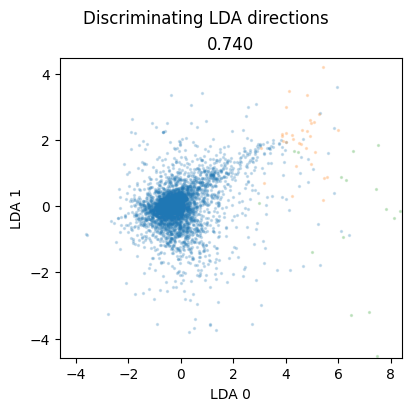

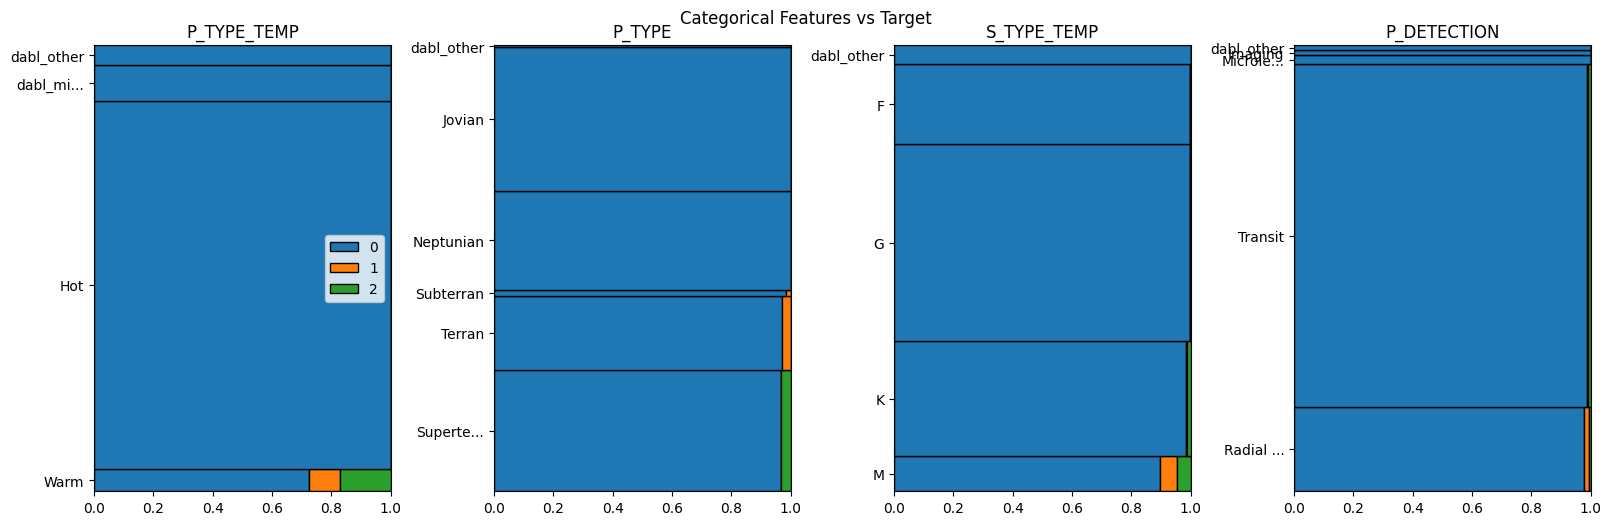

In [223]:
import warnings
warnings.filterwarnings('ignore')
db.plot(df, target_col='P_HABITABLE')

In [224]:
count = df['P_HABITABLE'].value_counts().sort_index()
total = count.sum()
percentage  = (count/total)*100
print(f'Percentage of class Imbalance:  ${percentage}')

Percentage of class Imbalance:  $P_HABITABLE
0    98.641304
1     0.518775
2     0.839921
Name: count, dtype: float64


Clearly the dataset is imabalnce as it have 98% inhabitable planets, 0.83% potentially habitable and 0.51% habitable planets.

We can resolve the class Imbalance with simple oversampling strateg


In [225]:
inhabitable = df[df.P_HABITABLE == 0]
potential_habitable = df[df.P_HABITABLE == 1]
habitable = df[df.P_HABITABLE == 2]

potential_habitable_oversampled = resample(potential_habitable, replace = True, n_samples=len(inhabitable), random_state=42)

oversampled = pd.concat([inhabitable, potential_habitable_oversampled])

habitable_oversampled = resample(habitable, replace=True, n_samples=len(inhabitable), random_state=42)

oversampled = pd.concat([oversampled,habitable_oversampled])

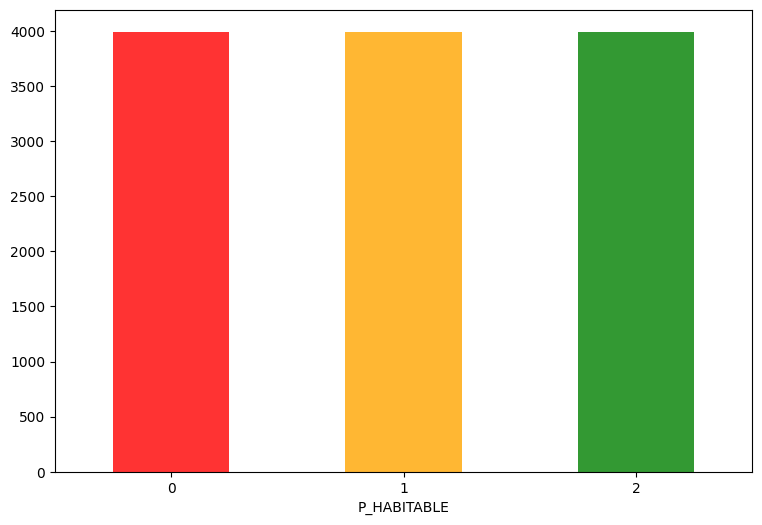

In [226]:
#plotting the new balanced target column
fig = plt.figure(figsize = (9,6))
oversampled.P_HABITABLE.value_counts(ascending = False).plot(kind = 'bar', color=['red', 'orange', 'green'], alpha = 0.8 , rot =0 )

plt.savefig("Resampled-plot.png")
plt.show()

In [227]:
oversampled['P_HABITABLE'].value_counts()

P_HABITABLE
0    3993
1    3993
2    3993
Name: count, dtype: int64

# **Data Analysis Through Visualization**

We can visualize, what techniques were used to detect exoplanets

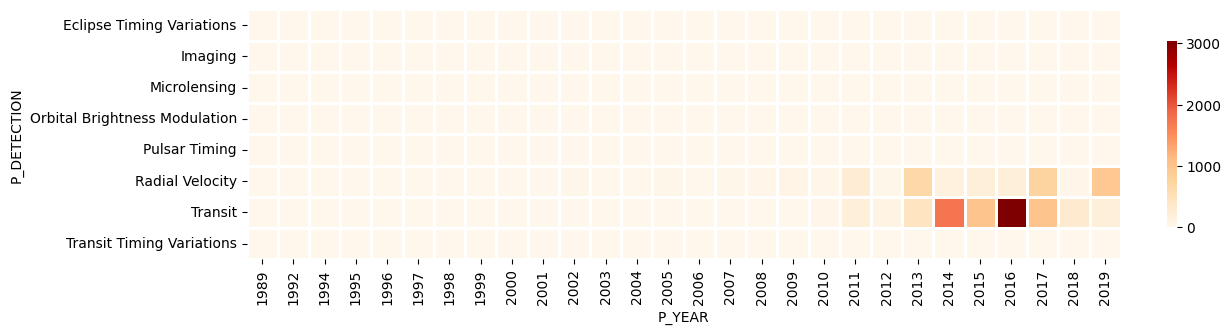

In [228]:
planet_detect = (oversampled.groupby("P_DETECTION").filter(lambda x: len(x)>5)).groupby(['P_DETECTION', 'P_YEAR']).size().unstack(fill_value=0)

plt.figure(figsize=(12,12))
g = sns.heatmap(
    planet_detect, 
    square=True, 
    cbar_kws={'fraction' : 0.01}, 
    cmap='OrRd',
    linewidth=1
)

We can observe that Transit and Radial Velocity detection technique had been used extensively for discovering exoplanets

Now we can plot habitability of these planets detected by the two detection methods

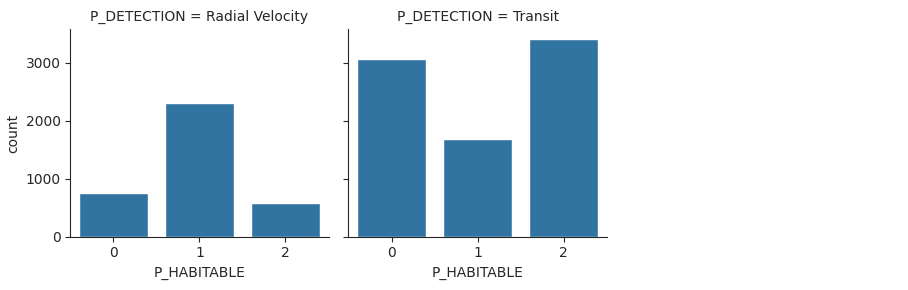

In [229]:
with sns.axes_style(style='ticks'):
    g = sns.catplot(x = "P_HABITABLE", 
                    col="P_DETECTION", 
                    col_wrap=3, 
                    data=oversampled[
                        oversampled['P_DETECTION'].isin(['Radial Velocity','Transit'])],
                    kind="count",
                    height=3.0, 
                    aspect=1.0)

Radial Velocity technique detected potentially habitual exoplanets and Transit method discovered more habitual and inhabitable planets more

Now we can analyze which planet (under which star) was discovered in which year.

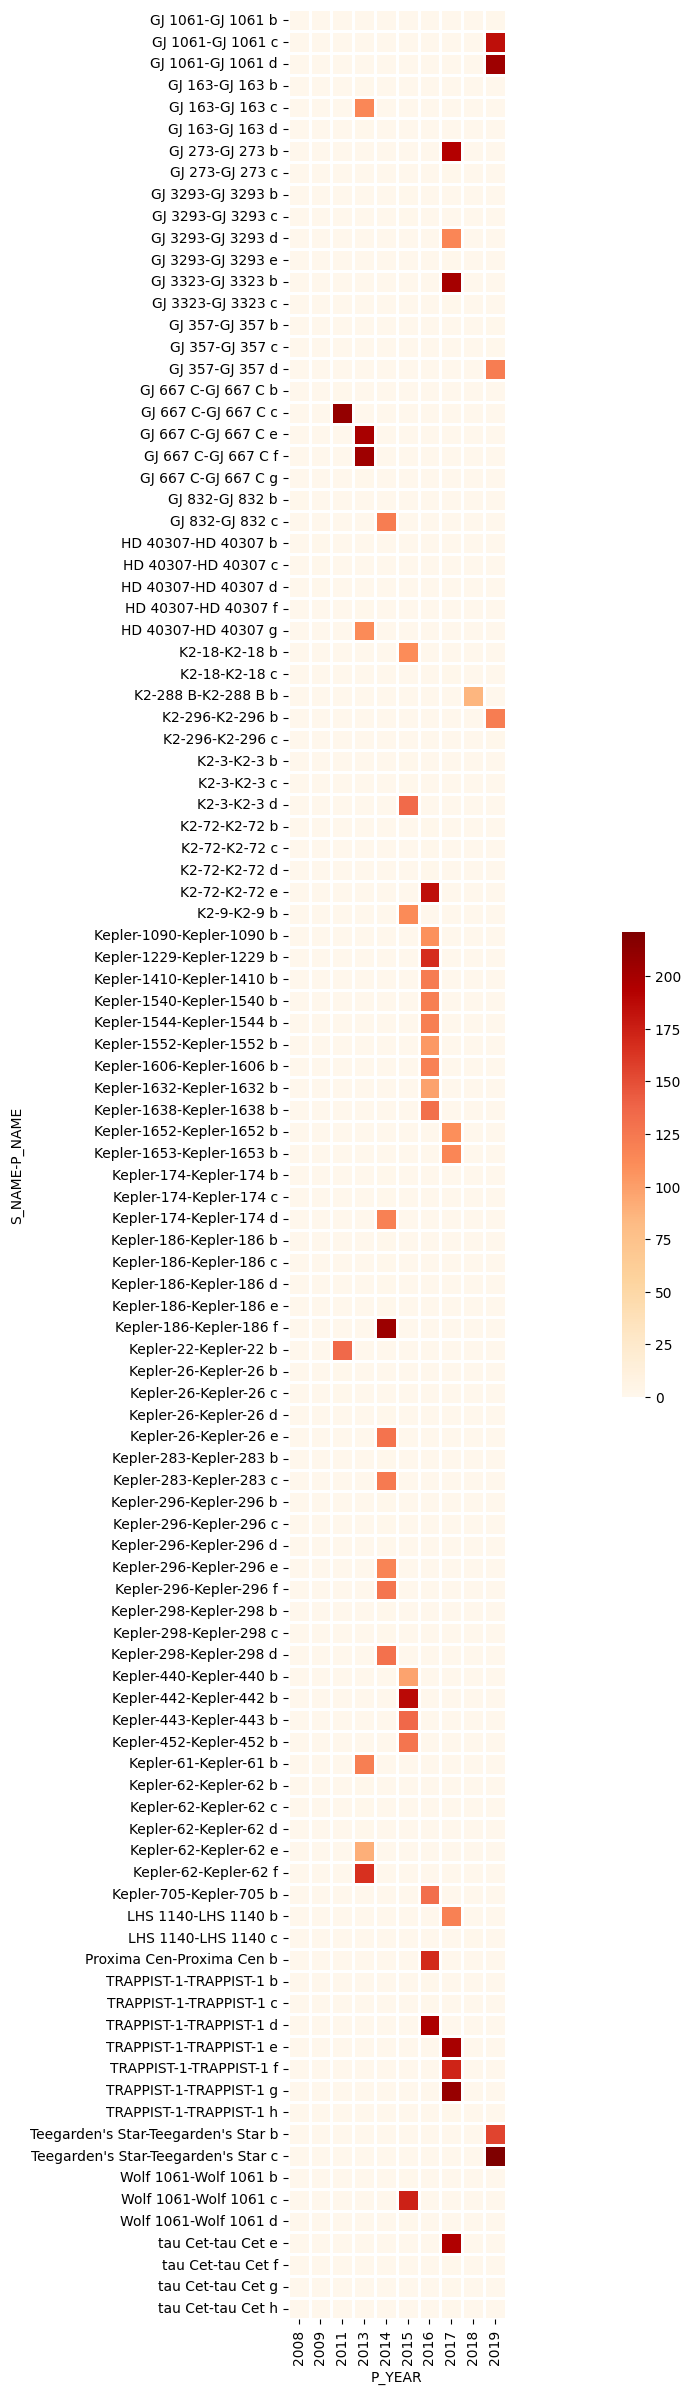

In [230]:
planet_under_star = (oversampled.groupby("S_NAME").filter(lambda x: len(x)>10).
groupby(['S_NAME', 'P_NAME', 'P_YEAR']).size().unstack(fill_value = 0))

plt.figure(figsize=(30,30))

g = sns.heatmap(planet_under_star,square=True, cbar_kws={'fraction':0.01},cmap='OrRd', linewidths=1)

We can observe that for star series GJ667, planets were discovered in 2008-2009, for Kepler series star, planets were discovered in somewhere 2011-2014 and for Trapist and Teegarden series star they were discovered in between 2017-2019

### **PREPRCESSING**

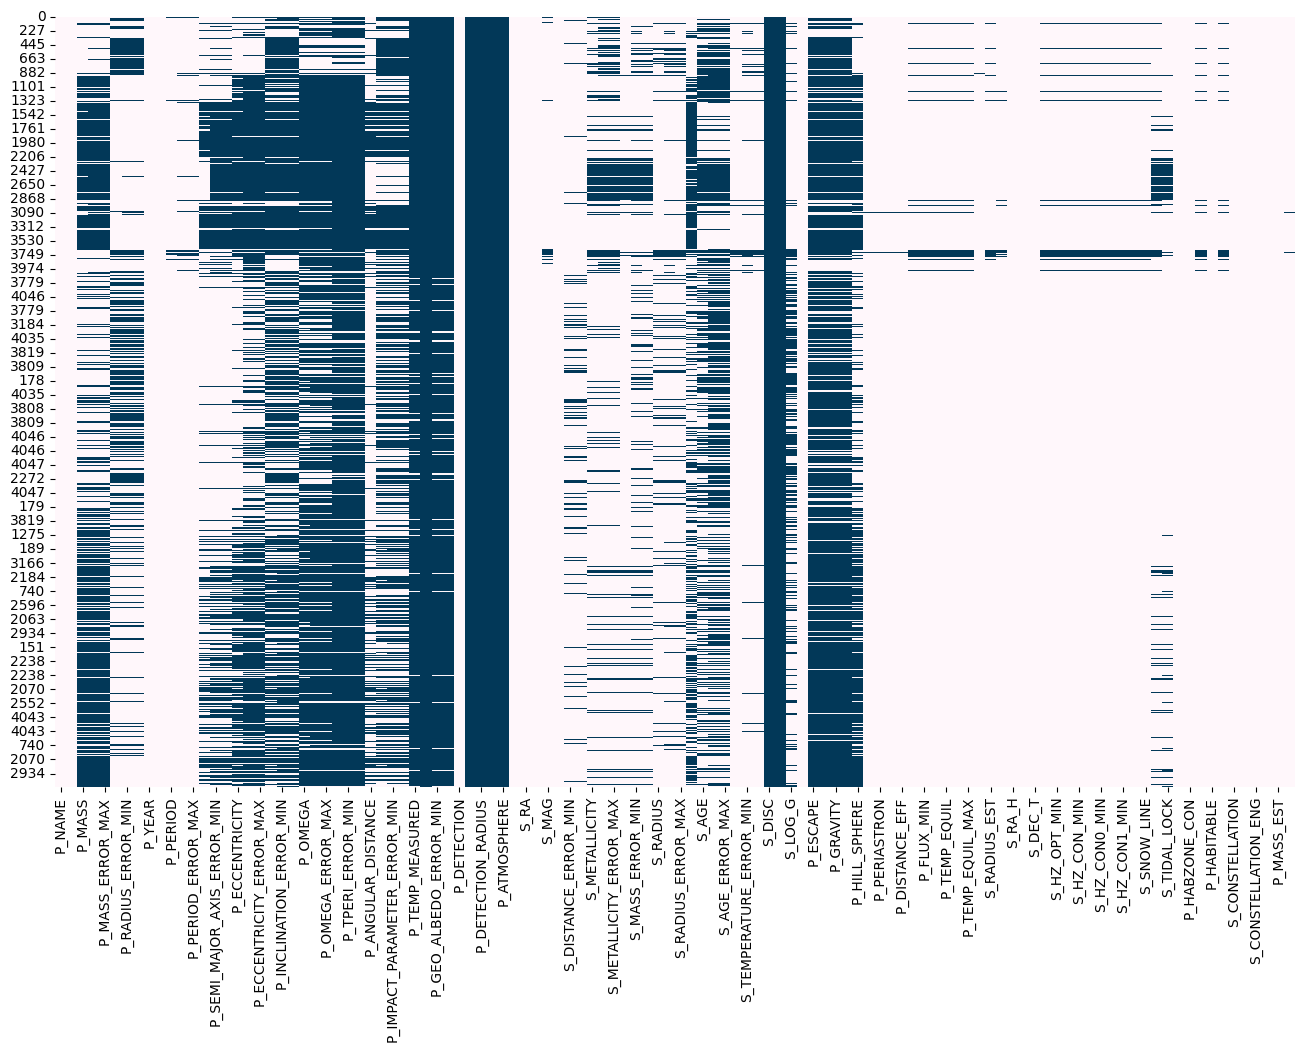

In [231]:
#Plots a heatmap of the missing values in the dataset
plt.figure(figsize=(16, 10))

sns.heatmap(oversampled.isnull(), cbar=False, cmap='PuBu') 
plt.show()

In [78]:
null_values = oversampled.isnull().sum().sort_values(ascending = False)
percent = (oversampled.isnull().sum()/oversampled.isnull().count()).sort_values(ascending=False)

missing = pd.concat([null_values,percent], axis = 1, keys=['Total', "Percent"])
missing.head(40)

,Total,Percent
P_ATMOSPHERE,11979,1.000000
P_ALT_NAMES,11979,1.000000
P_DETECTION_RADIUS,11979,1.000000
P_GEO_ALBEDO,11979,1.000000
P_DETECTION_MASS,11979,1.000000
S_MAGNETIC_FIELD,11979,1.000000
S_DISC,11979,1.000000
P_TEMP_MEASURED,11468,0.957342
P_GEO_ALBEDO_ERROR_MIN,11468,0.957342
P_GEO_ALBEDO_ERROR_MAX,11468,0.957342


We can safely remove those features which have missing values > 50% of data to reduce bias.

In [232]:
#Dropping all the columns with null  values
oversampled = oversampled.drop(["P_ATMOSPHERE","P_ALT_NAMES","P_DETECTION_RADIUS","P_GEO_ALBEDO","P_DETECTION_MASS","S_MAGNETIC_FIELD","S_DISC","P_TEMP_MEASURED","P_GEO_ALBEDO_ERROR_MIN","P_GEO_ALBEDO_ERROR_MAX","P_TPERI_ERROR_MAX","P_TPERI_ERROR_MIN",'P_TPERI','P_ESCAPE','P_POTENTIAL','P_DENSITY','P_GRAVITY','P_OMEGA_ERROR_MIN','P_OMEGA_ERROR_MAX','P_OMEGA','P_INCLINATION_ERROR_MAX','P_INCLINATION_ERROR_MIN',"P_INCLINATION","P_ECCENTRICITY_ERROR_MIN","P_ECCENTRICITY_ERROR_MAX","S_AGE_ERROR_MAX","S_AGE_ERROR_MIN",'P_IMPACT_PARAMETER_ERROR_MAX','P_IMPACT_PARAMETER_ERROR_MIN','P_IMPACT_PARAMETER','P_MASS_ERROR_MAX','P_MASS_ERROR_MIN',
"P_HILL_SPHERE",
"P_MASS"], axis=1)

In [233]:
oversampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11979 entries, 0 to 137
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   P_NAME                       11979 non-null  object 
 1   P_STATUS                     11979 non-null  float64
 2   P_RADIUS                     8195 non-null   float64
 3   P_RADIUS_ERROR_MIN           8161 non-null   float64
 4   P_RADIUS_ERROR_MAX           8161 non-null   float64
 5   P_YEAR                       11979 non-null  int64  
 6   P_UPDATED                    11979 non-null  object 
 7   P_PERIOD                     11869 non-null  float64
 8   P_PERIOD_ERROR_MIN           11738 non-null  float64
 9   P_PERIOD_ERROR_MAX           11738 non-null  float64
 10  P_SEMI_MAJOR_AXIS            8969 non-null   float64
 11  P_SEMI_MAJOR_AXIS_ERROR_MIN  7668 non-null   float64
 12  P_SEMI_MAJOR_AXIS_ERROR_MAX  7669 non-null   float64
 13  P_ECCENTRICITY         

Our data is divided into categorical and numeric datatypes

In [234]:
oversampled.select_dtypes(include=['object']).columns

Index(['P_NAME', 'P_UPDATED', 'P_DETECTION', 'S_NAME', 'S_TYPE', 'S_ALT_NAMES',
       'P_TYPE', 'S_TYPE_TEMP', 'S_RA_T', 'S_DEC_T', 'P_TYPE_TEMP',
       'S_CONSTELLATION', 'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object')

In [235]:
categorical = oversampled.select_dtypes(include=['object'])

In [236]:
total = categorical.isnull().sum().sort_values(ascending = False)
percent = (categorical.isnull().sum()/categorical.isnull().count()).sort_values(ascending=False)

missing = pd.concat([total,percent], axis = 1, keys=['Total', "Percent"])
missing.head(40)

,Total,Percent
S_TYPE,5852,0.488522
P_TYPE_TEMP,327,0.027298
S_TYPE_TEMP,136,0.011353
P_TYPE,17,0.001419
P_UPDATED,0,0.000000
P_NAME,0,0.000000
S_ALT_NAMES,0,0.000000
S_NAME,0,0.000000
P_DETECTION,0,0.000000
S_RA_T,0,0.000000


We can fill the missing values by imputation using mode

In [237]:
oversampled['P_TYPE'] = oversampled['P_TYPE'].fillna(oversampled['P_TYPE'].mode()[0]) #set the first most common value
oversampled['P_TYPE_TEMP'] = oversampled['P_TYPE_TEMP'].fillna(oversampled['P_TYPE_TEMP'].mode()[0])
oversampled['S_TYPE'] = oversampled['S_TYPE'].fillna(oversampled['S_TYPE'].mode()[0])
oversampled['S_TYPE_TEMP'] = oversampled['S_TYPE_TEMP'].fillna(oversampled['S_TYPE_TEMP'].mode()[0]) 

Now we can convert categorical column to numeric by label encoding

In [238]:
#Converting sll the categorical data into integer data
lencoders = {}
for col in oversampled.select_dtypes(include=['object']).columns:
    lencoders[col] = LabelEncoder()
    oversampled[col] = lencoders[col].fit_transform(oversampled[col])

nOw WE HANDLED MISSING VALUES IN CATEGORICAL DATA and encoded them, NO WE WILL WORK UPON NUMERICAL DATA 

We are going to use Scikit-learn's imputer because it provides a systematic way to replace missing numerical data, and IterativeImputer is particularly useful when we want to use relationships between multiple features to make those replacements.


In [239]:
imputed_data = oversampled.copy(deep=True)
imp = IterativeImputer() #Creates an iterative imputer object
imputed_data.iloc[:,:] = imp.fit_transform(oversampled)

In [240]:
imputed_data.head()


,P_NAME,P_STATUS,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,P_PERIOD,P_PERIOD_ERROR_MIN,P_PERIOD_ERROR_MAX,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,0,3.0,2.732468,-0.241494,0.312194,2007,0,326.03000,-0.32,0.32,...,0,1,0,0.083813,24,24,5,12.082709,6165.86330,1.29
1,1,3.0,2.732468,-0.241494,0.312194,2009,146,516.21997,-3.20,3.20,...,0,1,0,0.082414,83,83,42,12.229641,4684.78480,1.53
2,2,3.0,2.732468,-0.241494,0.312194,2008,0,185.84000,-0.23,0.23,...,0,1,0,0.081917,0,0,2,12.848516,1525.57440,0.83
3,3,3.0,2.732468,-0.241494,0.312194,2002,146,1773.40000,-2.50,2.50,...,0,0,0,0.145241,39,39,34,12.865261,1481.07850,2.93
4,4,3.0,2.732468,-0.241494,0.312194,1996,146,798.50000,-1.00,1.00,...,1,2,0,0.368627,30,30,75,13.421749,565.73385,1.66


In [241]:
imputed_data.isna().sum(axis =0)

P_NAME                   0
P_STATUS                 0
P_RADIUS                 0
P_RADIUS_ERROR_MIN       0
P_RADIUS_ERROR_MAX       0
                        ..
S_CONSTELLATION_ABR      0
S_CONSTELLATION_ENG      0
P_RADIUS_EST             0
P_MASS_EST               0
P_SEMI_MAJOR_AXIS_EST    0
Length: 78, dtype: int64

we have corrected all of our missing values!

Now we can work with fixing multicollinearity 

<Axes: >

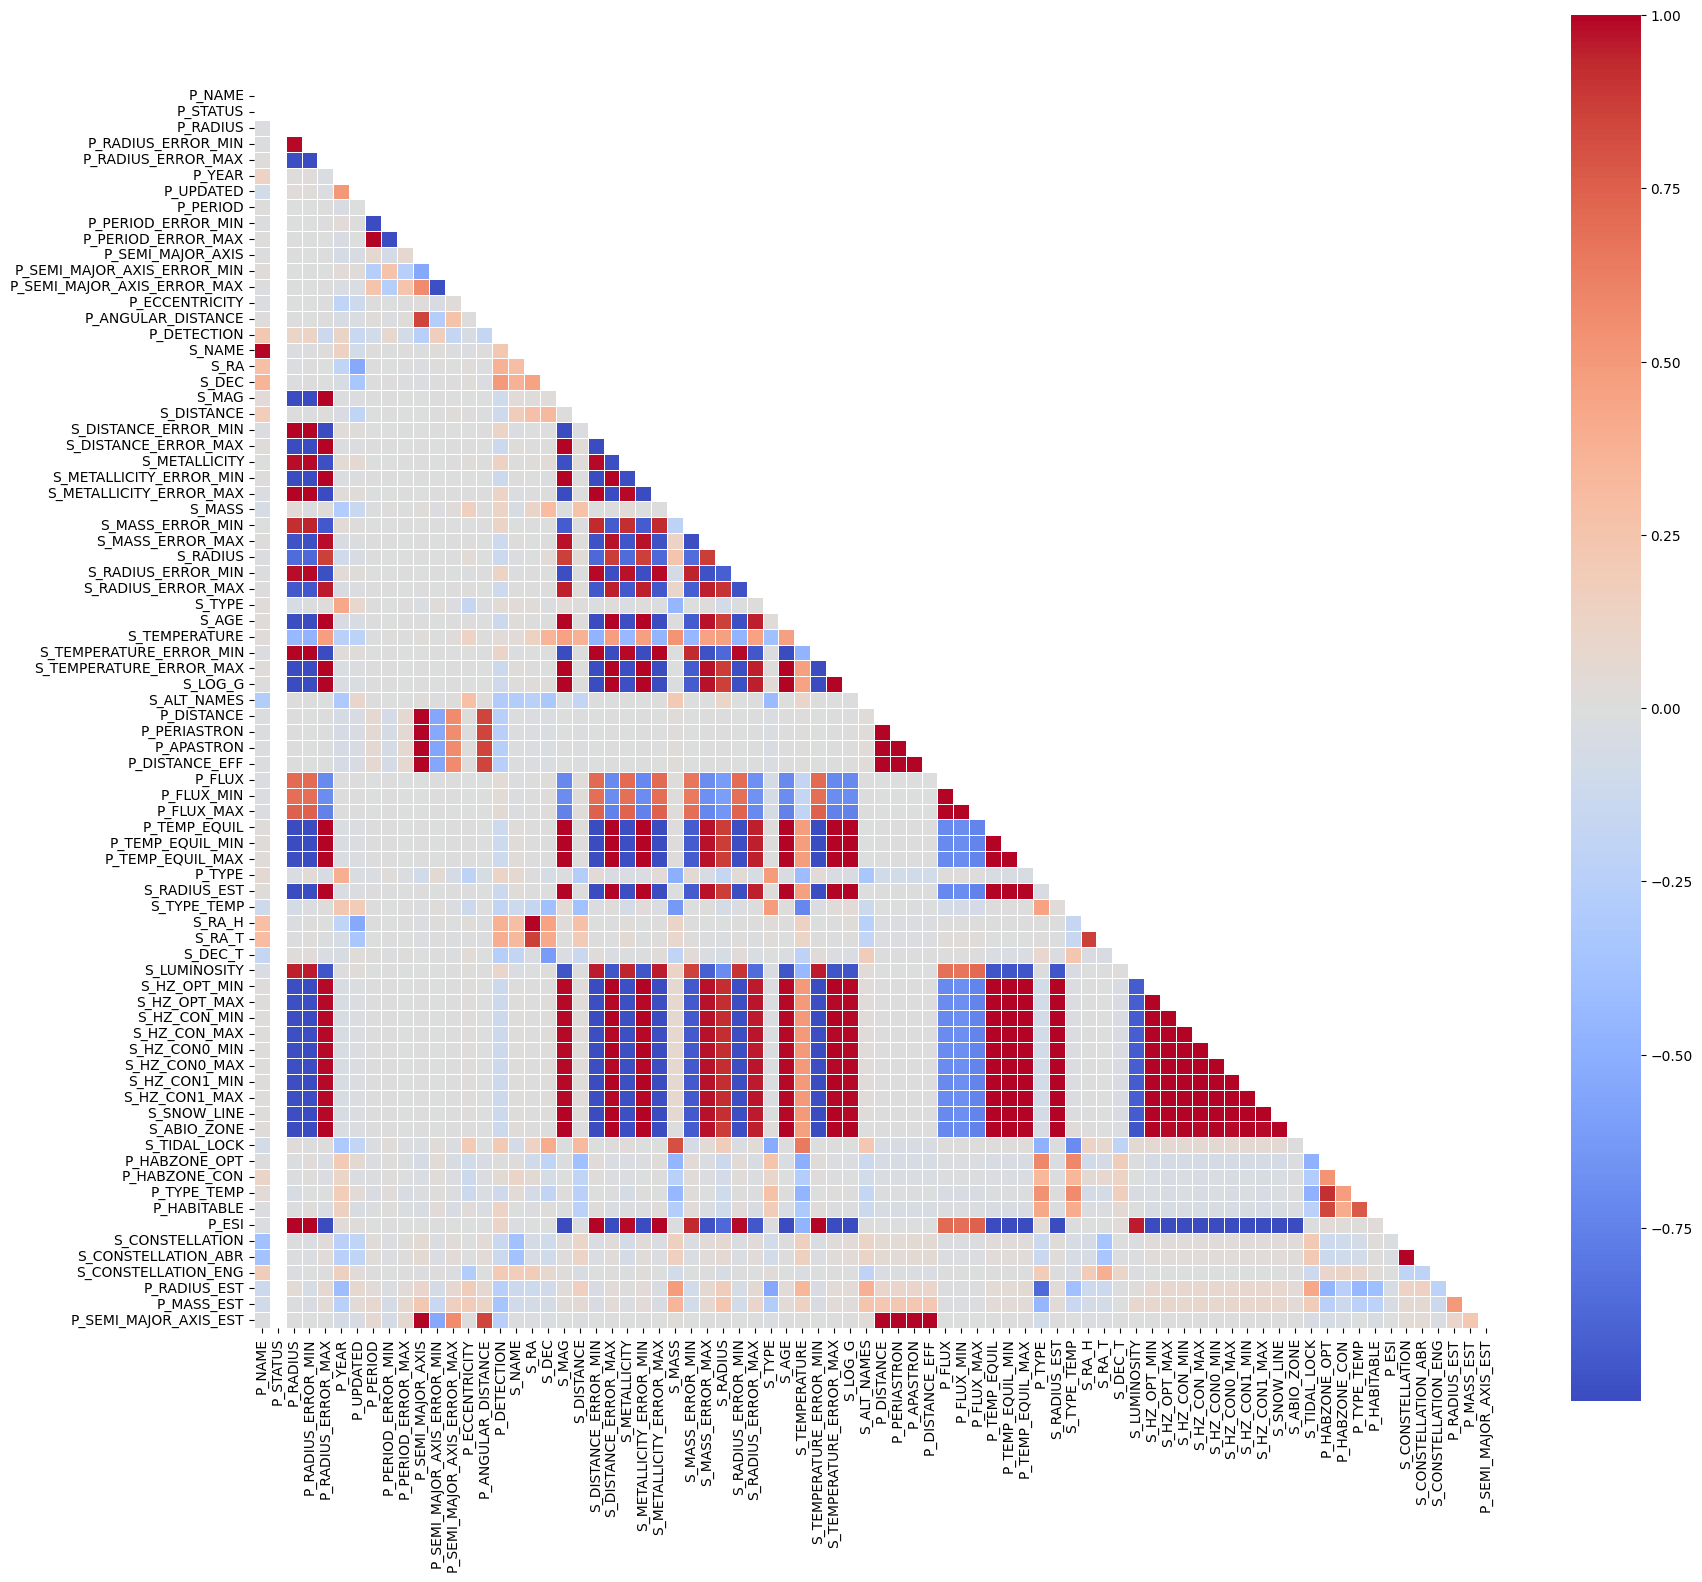

In [242]:
corr = imputed_data.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

Dark red square are the one which shows, features which are highly co-related. We can drop one of each.

In [243]:
#Dropping one of each which are highly corelated to each other
working_data = imputed_data.drop(['S_NAME', 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST', 'S_RA_H', 'S_RA_T', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'S_MAG', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_AGE', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_ABIO_ZONE', 'P_ESI', 'S_CONSTELLATION_ABR', 'P_SEMI_MAJOR_AXIS_EST'], axis=1)

<Axes: >

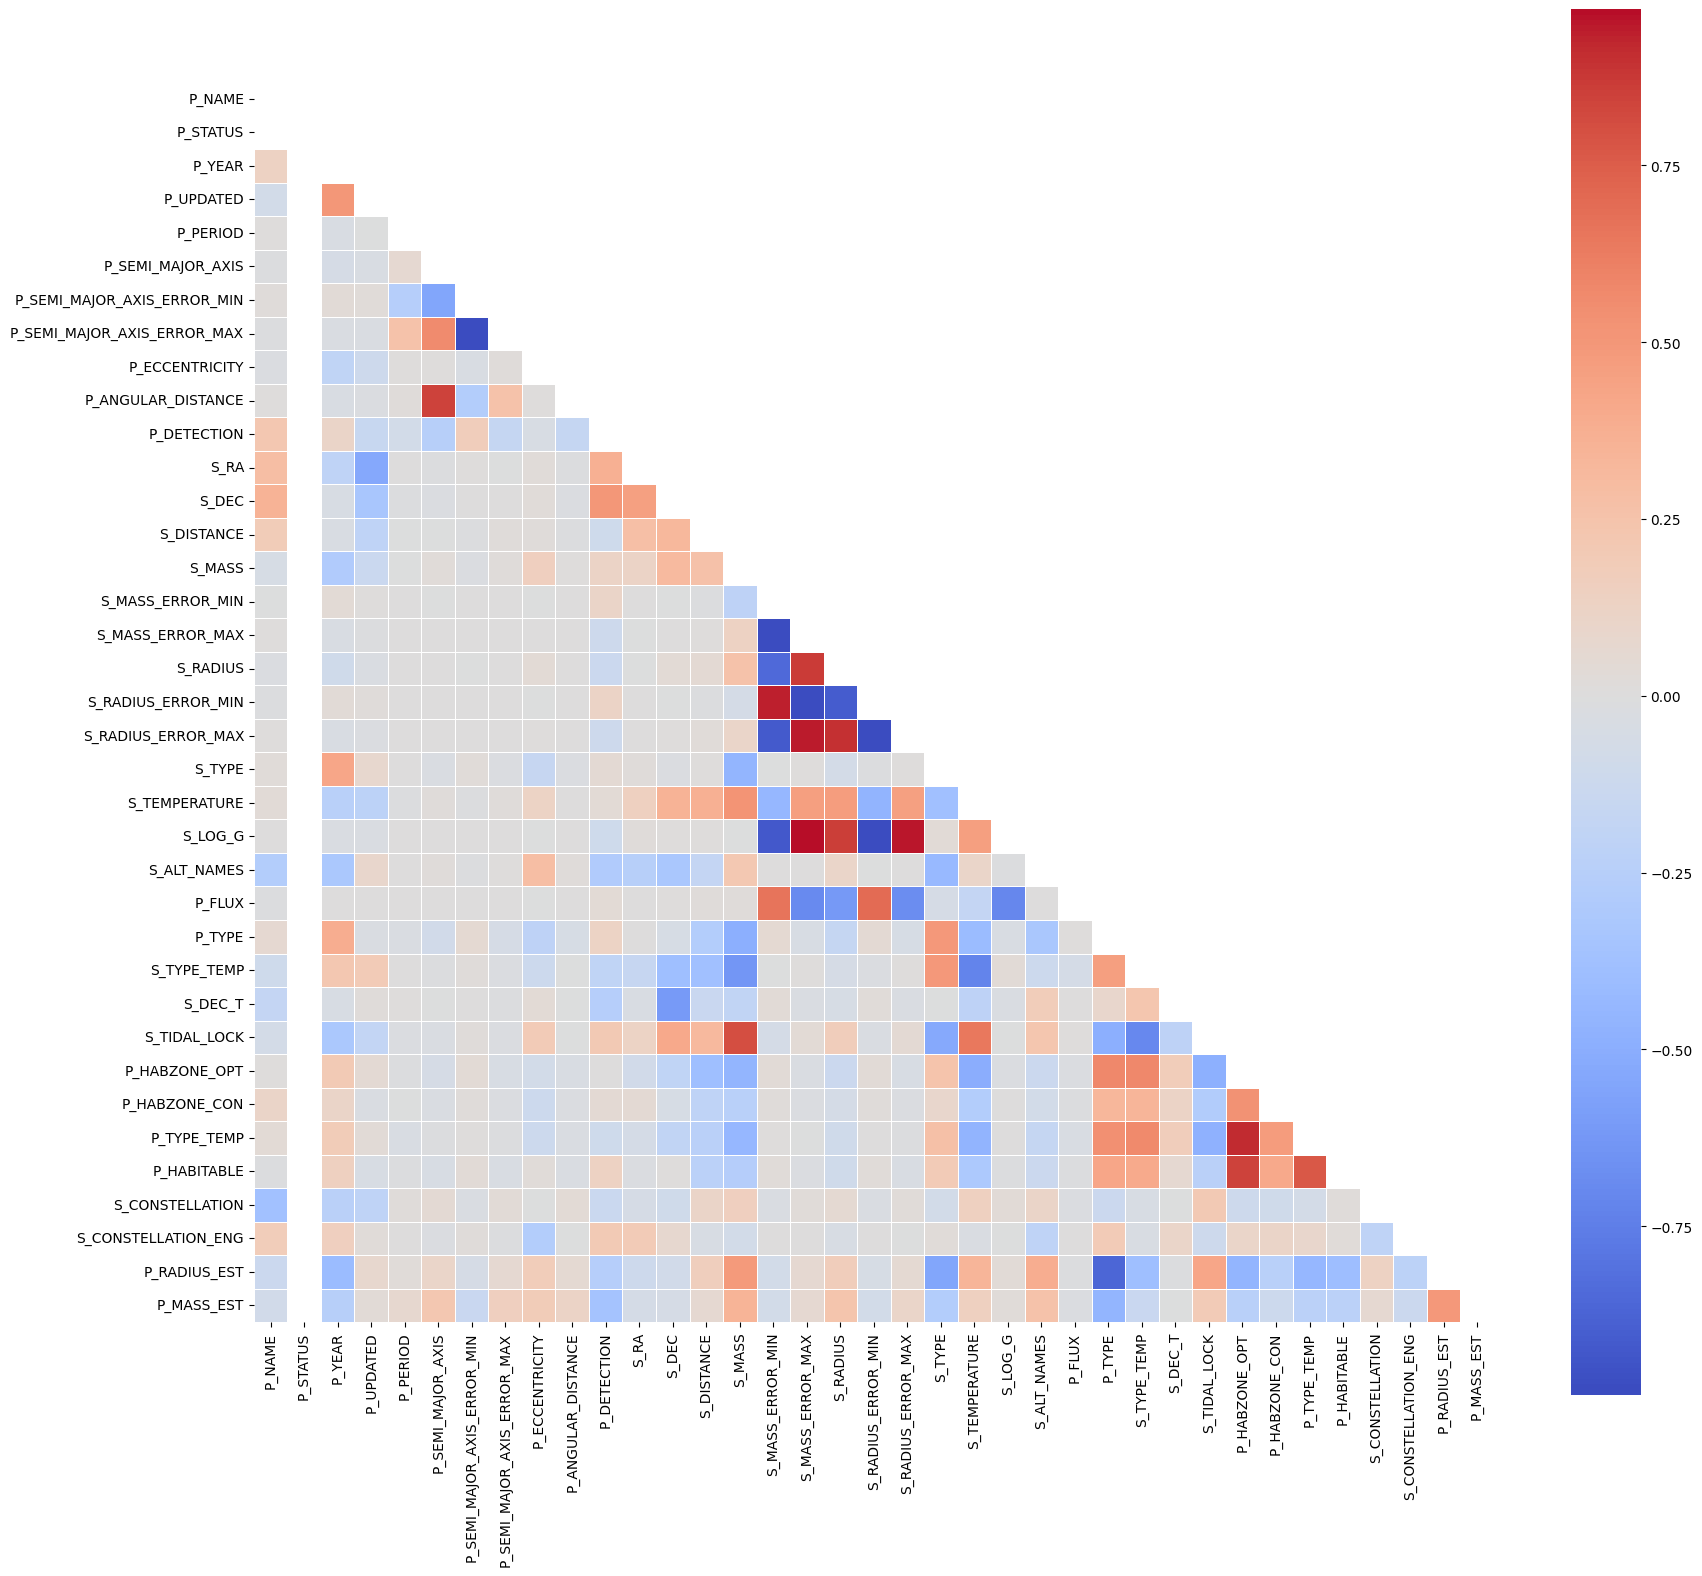

In [244]:
corr = working_data.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

Now we can work upon detecting outliers and removing them

In [245]:
Q1 = working_data.quantile(0.25)
Q3 = working_data.quantile(0.75)
IQR = Q3-Q1
print(IQR)

P_NAME                         2151.500000
P_STATUS                          0.000000
P_YEAR                            3.000000
P_UPDATED                        81.000000
P_PERIOD                        101.281293
P_SEMI_MAJOR_AXIS                 1.830351
P_SEMI_MAJOR_AXIS_ERROR_MIN       0.071672
P_SEMI_MAJOR_AXIS_ERROR_MAX       0.103664
P_ECCENTRICITY                    0.054474
P_ANGULAR_DISTANCE               59.120217
P_DETECTION                       1.000000
S_RA                            122.433590
S_DEC                            54.138227
S_DISTANCE                      492.570000
S_MASS                            0.520000
S_MASS_ERROR_MIN                  0.050000
S_MASS_ERROR_MAX                  0.050000
S_RADIUS                          0.502873
S_RADIUS_ERROR_MIN                0.061102
S_RADIUS_ERROR_MAX                0.088280
S_TYPE                            0.000000
S_TEMPERATURE                  2017.530000
S_LOG_G                           0.418985
S_ALT_NAMES

In [246]:
#Removing outliers

working_data = working_data[
    ~(
    ( working_data < (Q1-1.5 *IQR)) | 
    (working_data > (Q3+1.5 * IQR))
    ).any(axis=1)
]

# **FEATURE SELECTION**

Now that we have processed and analyzed all the data, we can finally select those features which are really important

For selecting the important features, we will separate them using 2 techniques

1) Random Forest feature Importance
2) Permutation Importance

In [247]:
X = working_data.drop("P_HABITABLE", axis = 1)
y = working_data['P_HABITABLE']

In [248]:
#Random Forest Classifier feature importance
selector = SelectFromModel(RandomForestClassifier(n_estimators=1000, random_state=0))
selector.fit(X,y)

support = selector.get_support()
features = X.loc[:,support].columns.tolist()
print(features)
print(RandomForestClassifier(n_estimators=1000, random_state=0).fit(X,y).feature_importances_) 

['P_PERIOD', 'P_ECCENTRICITY', 'S_DEC', 'S_DISTANCE', 'S_MASS', 'S_TEMPERATURE', 'P_FLUX', 'P_TYPE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_TYPE_TEMP', 'P_RADIUS_EST', 'P_MASS_EST']
[7.70566654e-03 0.00000000e+00 8.52260779e-04 6.33697039e-03
 3.09527117e-02 1.18515349e-02 1.63313373e-02 1.27200348e-02
 4.98928615e-02 1.44598273e-02 1.39839820e-04 8.95012187e-03
 3.37579420e-02 8.18331521e-02 5.90430613e-02 3.85202178e-03
 3.29387914e-03 4.24097494e-03 1.49806695e-03 1.68220577e-03
 0.00000000e+00 4.26625420e-02 1.16605199e-02 0.00000000e+00
 5.48996011e-02 8.16018157e-02 1.20537135e-02 2.18953721e-02
 4.53037643e-02 5.14952021e-02 2.74200438e-03 5.17319787e-02
 1.00951128e-03 9.20878841e-04 1.43315007e-01 1.29313618e-01]


In [ ]:
# Permutation Importance
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.ensemble import RandomForestClassifier as rf

rf_model = RandomForestClassifier(n_estimators=1000, random_state=0)
rf_model.fit(X,y)

perm = PermutationImportance(rf_model, random_state=1)

perm.fit(X,y)

eli5.show_weights(perm, feature_names = X.columns.tolist())

Weight,Feature
0 ± 0.0000,S_MASS_ERROR_MAX
0 ± 0.0000,S_RADIUS
0 ± 0.0000,S_RADIUS_ERROR_MIN
0 ± 0.0000,S_RADIUS_ERROR_MAX
0 ± 0.0000,S_TYPE
0 ± 0.0000,S_TEMPERATURE
0 ± 0.0000,S_LOG_G
0 ± 0.0000,S_ALT_NAMES
0 ± 0.0000,P_FLUX
0 ± 0.0000,P_TYPE


From both the sets of feature importance, we will chose the one which was common in both.

## **Splitting into Train/Test**

In [270]:
features = working_data[['P_PERIOD','S_DEC','S_DISTANCE','S_MASS','S_TEMPERATURE','P_TYPE','S_TIDAL_LOCK','P_RADIUS_EST']]

target = working_data["P_HABITABLE"]

X_train, X_test, y_train, y_test = train_test_split(features, target , test_size=0.20, random_state=42)

print("Training/testing: ", len(X_train), '/', len(X_test))

Training/testing:  3108 / 777


In [271]:
#Scaling the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **TRAINING**

Since our target column is of multi-class, we will use one-vs-rest strategy. This strategy breaks down multi class problem to binary class and then compares them.

In [272]:
def run_models(model, X_train, y_train, X_test, y_test, verbose=True):

    if verbose == False:
        model_ovr = Ovr(model)
        model_ovr.fit(X_train, y_train, verbose = 0)
    else:
        model_ovr = Ovr(model)
        model_ovr.fit(X_train,y_train)

    y_pred = model_ovr.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    recall  = recall_score(y_test, y_pred, average='macro')

    print("Accuracy = {}".format(accuracy))
    print("Precision = {}".format(precision))
    print("F1 score = {}".format(f1))
    print("Recall Score = {}".format(recall))
    print(classification_report(y_test, y_pred, digits = 5))

    return accuracy, precision, f1, recall

Training all the different models

In [ ]:
#Logistic Regression
model_lr = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')

param_grid_lr = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1],  
    'penalty': ['l2'],
    'class_weight': ['balanced'] 
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(model_lr, param_grid_lr, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_

accuracy_lr, precision_lr, f1_lr, recall_lr = run_models(model_lr, X_train, y_train,X_test, y_test)

Accuracy = 0.9884169884169884
Precision = 0.9912764039659834
F1 score = 0.9719823047254099
Recall Score = 0.9558823529411765
              precision    recall  f1-score   support

           0    1.00000   0.86765   0.92913        68
           1    0.99241   1.00000   0.99619       392
           2    0.98142   1.00000   0.99062       317

    accuracy                        0.98842       777
   macro avg    0.99128   0.95588   0.97198       777
weighted avg    0.98859   0.98842   0.98805       777



In [ ]:
#Decision Tree

dt = DecisionTreeClassifier(random_state=42)


param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],           
    'min_samples_split': [20, 30, 50],    
    'min_samples_leaf': [10, 15, 20],     
    'max_features': ['sqrt', 'log2'] 
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)


best_dt = grid_search.best_estimator_

accuracy_dt, precision_dt, f1_dt, recall_dt = run_models(best_dt,X_train,y_train,X_test,y_test)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters:
{'criterion': 'gini', 'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 20}

Best CV Macro F1:
0.9686058597027174
Accuracy = 0.9974259974259975
Precision = 0.9983079526226734
F1 score = 0.9941766992011951
Recall Score = 0.9901960784313726
              precision    recall  f1-score   support

           0    1.00000   0.97059   0.98507        68
           1    0.99492   1.00000   0.99746       392
           2    1.00000   1.00000   1.00000       317

    accuracy                        0.99743       777
   macro avg    0.99831   0.99020   0.99418       777
weighted avg    0.99744   0.99743   0.99741       777



In [ ]:
#Gradient Boosting

gb = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],           
    'learning_rate': [0.001, 0.01],      
    'max_depth': [2, 3, 4],              
    'min_samples_split': [30, 50],       
    'min_samples_leaf': [15, 20],        
    'subsample': [0.6, 0.7],             
    'max_features': ['sqrt'] 
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_gb = GridSearchCV(gb, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_

accuracy_gb, precision_gb, f1_gb, recall_gb = run_models(
    best_gb, X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


Accuracy = 0.9832689832689833
Precision = 0.9879600963192295
F1 score = 0.9586947951891024
Recall Score = 0.9362745098039215
              precision    recall  f1-score   support

           0    1.00000   0.80882   0.89431        68
           1    0.98246   1.00000   0.99115       392
           2    0.98142   1.00000   0.99062       317

    accuracy                        0.98327       777
   macro avg    0.98796   0.93627   0.95869       777
weighted avg    0.98357   0.98327   0.98246       777



In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    rf, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1
)


grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_


accuracy_rf, precision_rf, f1_rf, recall_rf = run_models(
    best_rf, X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits
Accuracy = 0.9987129987129987
Precision = 0.9991518235793045
F1 score = 0.9971062357474247
Recall Score = 0.9950980392156863
              precision    recall  f1-score   support

           0    1.00000   0.98529   0.99259        68
           1    0.99746   1.00000   0.99873       392
           2    1.00000   1.00000   1.00000       317

    accuracy                        0.99871       777
   macro avg    0.99915   0.99510   0.99711       777
weighted avg    0.99872   0.99871   0.99871       777



# **MODEL COMPARISON**

In [296]:
results = {
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "Gradient Boosting Classifier",
        "Random Forest"
    ],
    "Accuracy": [
        0.9974259974259975,
        0.9884169884169884,
        0.9832689832689833,
        0.9987129987129987
    ],
    "Precision": [
        0.9983079526226734,
        0.9912764039659834,
        0.9879600963192295,
        0.9991518235793045
    ],
    "Recall": [
        0.9901960784313726,
        0.9558823529411765,
        0.9362745098039215,
        0.9950980392156863
    ],
    "F1 Score": [
        0.9941766992011951,
        0.9719823047254099,
        0.9586947951891024,
        0.9971062357474247
    ]
}
comparison_df = pd.DataFrame(results)

metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score"]
comparison_df[metric_columns] = comparison_df[metric_columns] * 100

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparison_df.round(2)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,99.87,99.92,99.51,99.71
1,Decision Tree,99.74,99.83,99.02,99.42
2,Logistic Regression,98.84,99.13,95.59,97.20
3,Gradient Boosting Classifier,98.33,98.80,93.63,95.87


In [295]:
best_model = comparison_df.iloc[0]

print("\n----- FINAL VERDICT -----")
print(f"Best Model: {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.2f}%")
print(f"Precision: {best_model['Precision']:.2f}%")
print(f"Recall   : {best_model['Recall']:.2f}%")
print(f"F1 Score : {best_model['F1 Score']:.2f}%")


----- FINAL VERDICT -----
Best Model: Random Forest
Accuracy : 99.87%
Precision: 99.92%
Recall   : 99.51%
F1 Score : 99.71%


In [299]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", rf_model)
])

joblib.dump(pipeline, "model.pkl")

['model.pkl']